In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import ExoWeave Coupler
from exoweave import ExoCoupler

from fuzzycore.utils import generate_gaussian_z_profile
from fuzzycore import constants as c


# Set A&A publication-ready plotting parameters
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.linewidth': 1.2
})

import os

# Put a leash on Intel MKL and all other C-level math libraries!
# This strictly prevents them from spawning deadlocking threads.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
# =============================================================================
# 1. SETUP SUB-NEPTUNE PARAMETERS
# =============================================================================
M_JUP_IN_EARTH = 317.83
target_mass_mjup = 8.17 * (c.M_EARTH / c.M_JUPITER)

base_params = {
    "mass": target_mass_mjup,
    "T_irr": 550.0,              # Surface equilibrium temperature (K)
    "T_int": 100.0,              # Deep internal heat flux (K)
    "Met": 1.0,                  # Bulk atmospheric metallicity (approx 5x solar)
    "core_mass_earth": 6.9,      # 7.0 M_earth core leaves 1.0 M_earth for the envelope!
    'M_water': 1.00, 
    "iron_fraction": 0.33,       # Earth-like rock/iron ratio
    "f_sed": 3.0,
    "kzz": 8.0,
    "g_1bar": 10.0,
    "debug": True
}

config = {
    "max_iterations": 20,              
    "mass_convergence_threshold": 0.01,
    "p_bottom_bar": 1000.0,
    "output_dir": "./outputs/subneptune_test",
    "resolution": 50,           
    "target_resolution": 50,
    "min_p_link_bar": 1    
}

# Define the two distinct architectures
params_sharp = base_params.copy()
params_sharp["sigma_val"] = 0.0  

params_fuzzy = base_params.copy()
params_fuzzy["sigma_val"] = 0.25  # Fuzzy Core (Dilute gradient, layered convection)

In [3]:
# =============================================================================
# 2. RUN THE COUPLED MODELS
# =============================================================================
#print(f'🚀 Launching Sharp Core Model (sigma = {params_sharp["sigma_val"]})...')
#coupler_sharp = ExoCoupler(target_params=params_sharp, config=config)
#results_sharp = coupler_sharp.run()

print("\n🚀 Launching Fuzzy Core Model (sigma = 0.30)...")
coupler_fuzzy = ExoCoupler(target_params=params_fuzzy, config=config)
results_fuzzy = coupler_fuzzy.run()


INFO: 🌌 Grid Setup: Generated mathematical cold-start prior down to 1000.0 bars.
INFO: 
INFO: 🔄 ITERATION 1/20 | Target Mass: 0.025706659641728136 M_Jup | g: 10.00 m/s²
INFO: ==================================================
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp2wfb25ye/input.nml


INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...



🚀 Launching Fuzzy Core Model (sigma = 0.30)...


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp2wfb25ye/outputs/exowrap_run.h5...
INFO: Simulation complete.
INFO: 🛡️ Convective top at 6.879e-02 bar is too shallow. Clamping to >= 1 bar.
INFO: 🔗 Dynamic Junction: Anchoring to thickest convective block at P = 1.19 bar
INFO: Calculating Z_base and Y_ratio from atmospheric VMRs at 1.188502227437018 bar.
INFO: 🧪 Chemical Sync: Derived Z_base = 0.0982, Y_ratio = 0.2538 (from X=0.6729, Y=0.2289)



🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: iter_1 | Mode: gravity
Target Value: 1.00000e+01 [m/s^2]
------------------------------------------------------------
Raw Parameters Dictionary:
  - P_surf: 1.188502227437018
  - T_surf: 1101.8775808557184
  - M_core: 4.121e+25 ⚠️ (MASSIVE NUMBER)
  - M_water: 5.972e+24 ⚠️ (MASSIVE NUMBER)
  - iron_fraction: 0.33
  - z_base: 0.09824677256736547
  - Y_ratio: 0.25382620123190114
  - sigma_val: 0.25
  - z_profile: ndarray (shape: (100,), mean: 0.379)
  - initial_log_pc: 9.0
  - debug: True

--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
  [Solver] Launching concentric bracket search a

...

INFO: 📊 Breakdown: Interior Mass = 0.0251 M_Jup
INFO: 📊 Breakdown: Atm Mass = 0.000000 M_Jup (0.000% of total)
INFO: 📊 Results: Total Calc Mass = 0.025 M_Jup (Error: -2.25%)
INFO: 📊 Results: True Measured T_int = 99.6 K (Input dial: 100.0 K)
INFO: Stitching profiles at P_link = 1.19 bar
INFO: 🌟 Computing Mega-Catalog Photometry (Cached)...
INFO: ✅ Successfully cached and computed 99 photometric bands!
INFO: 🎯 Secant Method applied to Mass target.
INFO: 
INFO: 🔄 ITERATION 3/20 | Target Mass: 0.025706659641728136 M_Jup | g: 10.47 m/s²
INFO: ==================================================
INFO: 🔥 Warm Start: Injecting P-T profile from iteration 2
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpopipgksw/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...
INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpopipgksw/output


🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: iter_3 | Mode: gravity
Target Value: 1.04675e+01 [m/s^2]
------------------------------------------------------------
Raw Parameters Dictionary:
  - P_surf: 1.188502227437018
  - T_surf: 1101.9465523656647
  - M_core: 4.121e+25 ⚠️ (MASSIVE NUMBER)
  - M_water: 5.972e+24 ⚠️ (MASSIVE NUMBER)
  - iron_fraction: 0.33
  - z_base: 0.09800457905713689
  - Y_ratio: 0.2537811230456654
  - sigma_val: 0.25
  - z_profile: ndarray (shape: (100,), mean: 0.379)
  - initial_log_pc: 9.0
  - debug: True

  [Smart Prior] Mined historical model. Prior guess set to logPc=6.750
  [Solver] Launching concentric bracket search around logPc=6.75...
  [Env Builder] Integrating from 1.19 to 1760.06 bar.
  [Env Builder] Z-jump 0.098->0.099: Entropy jumped from 64353.26 to 64280.69
  [Env Builder] Z-jump 0.099->0.100: Entropy jumped from 64280.69 to 64208.11
  [Env Builder] Z-jump 0.100->0.101: Entropy jumped from 64208.11 to 64135.50
  [Env Builder] Z-jump

INFO: 📊 Breakdown: Interior Mass = 0.0251 M_Jup
INFO: 📊 Breakdown: Atm Mass = 0.000000 M_Jup (0.000% of total)
INFO: 📊 Results: Total Calc Mass = 0.025 M_Jup (Error: -2.26%)
INFO: 📊 Results: True Measured T_int = 99.6 K (Input dial: 100.0 K)
INFO: Stitching profiles at P_link = 1.19 bar
INFO: 🌟 Computing Mega-Catalog Photometry (Cached)...
INFO: ✅ Successfully cached and computed 99 photometric bands!
INFO: 🎯 Secant Method applied to Mass target.
INFO: 
INFO: 🔄 ITERATION 4/20 | Target Mass: 0.025706659641728136 M_Jup | g: 5.23 m/s²
INFO: ==================================================
INFO: 🔥 Warm Start: Injecting P-T profile from iteration 3
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpuk8gf3ct/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...
INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpuk8gf3ct/outputs


🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: iter_4 | Mode: gravity
Target Value: 5.23374e+00 [m/s^2]
------------------------------------------------------------
Raw Parameters Dictionary:
  - P_surf: 1.188502227437018
  - T_surf: 1109.8463254847622
  - M_core: 4.121e+25 ⚠️ (MASSIVE NUMBER)
  - M_water: 5.972e+24 ⚠️ (MASSIVE NUMBER)
  - iron_fraction: 0.33
  - z_base: 0.0978812914372551
  - Y_ratio: 0.2536324553766957
  - sigma_val: 0.25
  - z_profile: ndarray (shape: (100,), mean: 0.379)
  - initial_log_pc: 9.0
  - debug: True

  [Smart Prior] Mined historical model. Prior guess set to logPc=6.740
  [Solver] Launching concentric bracket search around logPc=6.74...
  [Env Builder] Integrating from 1.19 to 52717.15 bar.
  [Env Builder] Z-jump 0.098->0.099: Entropy jumped from 64434.12 to 64361.45
  [Env Builder] Z-jump 0.099->0.100: Entropy jumped from 64361.45 to 64288.76
  [Env Builder] Z-jump 0.100->0.101: Entropy jumped from 64288.76 to 64216.01
  [Env Builder] Z-jump

INFO: 📊 Breakdown: Interior Mass = 0.0256 M_Jup
INFO: 📊 Breakdown: Atm Mass = 0.000000 M_Jup (0.000% of total)
INFO: 📊 Results: Total Calc Mass = 0.026 M_Jup (Error: -0.25%)
INFO: 📊 Results: True Measured T_int = 98.9 K (Input dial: 100.0 K)
INFO: Stitching profiles at P_link = 1.19 bar
INFO: 🌟 Computing Mega-Catalog Photometry (Cached)...
INFO: ✅ Successfully cached and computed 99 photometric bands!
INFO: ✅ CONVERGED in 4 iterations!
INFO: 💾 Converged model saved successfully to: /Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/subneptune_test/target/M_0.026_Tirr_550.0_Tint_98.9_Met_1.00_Core_6.9_fsed_3.0_kzz_8.0.pkl


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have a converged result to plot
if results_sharp['status'] == 'converged':
    df = results_sharp['stitched_profile']
    p_link = results_sharp['final_params']['p_link_bar']
    
    # Handle column names dynamically (in case your master profile uses meters instead of Jupiter Radii)
    if 'Radius_Rjup' in df.columns:
        r_col = 'Radius_Rjup'
        x_label = "Radius ($R_{Jup}$)"
    elif 'Radius_m' in df.columns:
        # Convert meters to Jupiter radii on the fly (1 R_Jup = 71,492,000 m)
        df['Radius_Rjup_tmp'] = df['Radius_m'] / 71492000.0
        r_col = 'Radius_Rjup_tmp'
        x_label = "Radius ($R_{Jup}$)"
    else:
        # Fallback if standard names aren't found
        r_col = [col for col in df.columns if 'rad' in col.lower()][0]
        x_label = "Radius"
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the continuous Radius vs. Pressure curve
    ax.plot(df[r_col], df['Pressure_bar'], color='teal', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 3. Format the axes (Log pressure, inverted so the deep core is at the bottom)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Planetary Radius vs. Pressure", fontsize=16)
    
    # 4. Fill background colors to show physical domains
    ax.axhspan(df['Pressure_bar'].min(), p_link, color='skyblue', alpha=0.1, label='Atmosphere (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior (fuzzycore)')
    
    # Add a grid for easier reading of specific depths
    plt.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper left')
    
    plt.show()
else:
    print("The model did not converge. Please check the logs!")

NameError: name 'results_sharp' is not defined

In [5]:
# 6. Visualize the continuous planetary profile
if results_sharp['status'] == 'converged':
    df = results_sharp['stitched_profile']
    p_link = results_sharp['final_params']['p_link_bar']
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the full stitched profile
    ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Extract and overlay the convective zones from the atmosphere!
    atm_raw = results_sharp['atmosphere_raw']
    p_atm_bar = atm_raw['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm = atm_raw['/outputs/levels/temperature'].iloc[0]
    is_conv = atm_raw['/outputs/levels/is_convective'].iloc[0].astype(bool)
    
    # Replace all non-convective temperatures with NaN
    t_conv = np.where(is_conv, t_atm, np.nan)
    
    # Plot the bold overlay (Matplotlib automatically skips the NaNs!)
    ax.plot(t_conv, p_atm_bar, color='orange', lw=7, zorder=2, label='Convective Zones (Atmosphere)')
    
    # 3. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 4. Format the axes for atmospheric science standards (log pressure, inverted)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)
    
    # 5. Fill background colors to show domains
    ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')
    
    ax.legend(loc='upper right')
    plt.show()

NameError: name 'results_sharp' is not defined

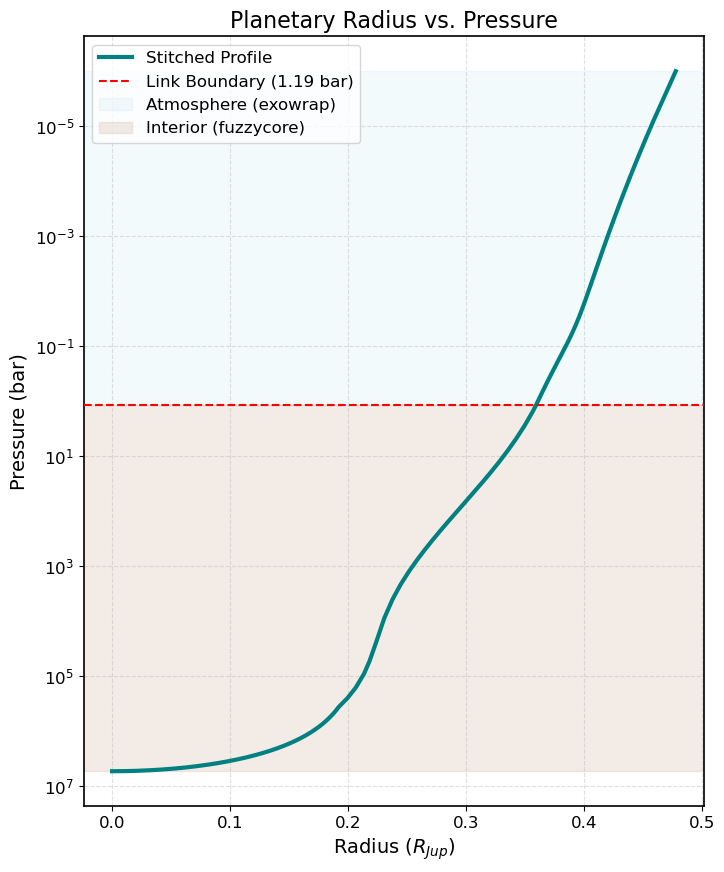

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have a converged result to plot
if results_fuzzy['status'] == 'converged':
    df = results_fuzzy['stitched_profile']
    p_link = results_fuzzy['final_params']['p_link_bar']
    
    # Handle column names dynamically (in case your master profile uses meters instead of Jupiter Radii)
    if 'Radius_Rjup' in df.columns:
        r_col = 'Radius_Rjup'
        x_label = "Radius ($R_{Jup}$)"
    elif 'Radius_m' in df.columns:
        # Convert meters to Jupiter radii on the fly (1 R_Jup = 71,492,000 m)
        df['Radius_Rjup_tmp'] = df['Radius_m'] / 71492000.0
        r_col = 'Radius_Rjup_tmp'
        x_label = "Radius ($R_{Jup}$)"
    else:
        # Fallback if standard names aren't found
        r_col = [col for col in df.columns if 'rad' in col.lower()][0]
        x_label = "Radius"
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the continuous Radius vs. Pressure curve
    ax.plot(df[r_col], df['Pressure_bar'], color='teal', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 3. Format the axes (Log pressure, inverted so the deep core is at the bottom)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Planetary Radius vs. Pressure", fontsize=16)
    
    # 4. Fill background colors to show physical domains
    ax.axhspan(df['Pressure_bar'].min(), p_link, color='skyblue', alpha=0.1, label='Atmosphere (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior (fuzzycore)')
    
    # Add a grid for easier reading of specific depths
    plt.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper left')
    
    plt.show()
else:
    print("The model did not converge. Please check the logs!")

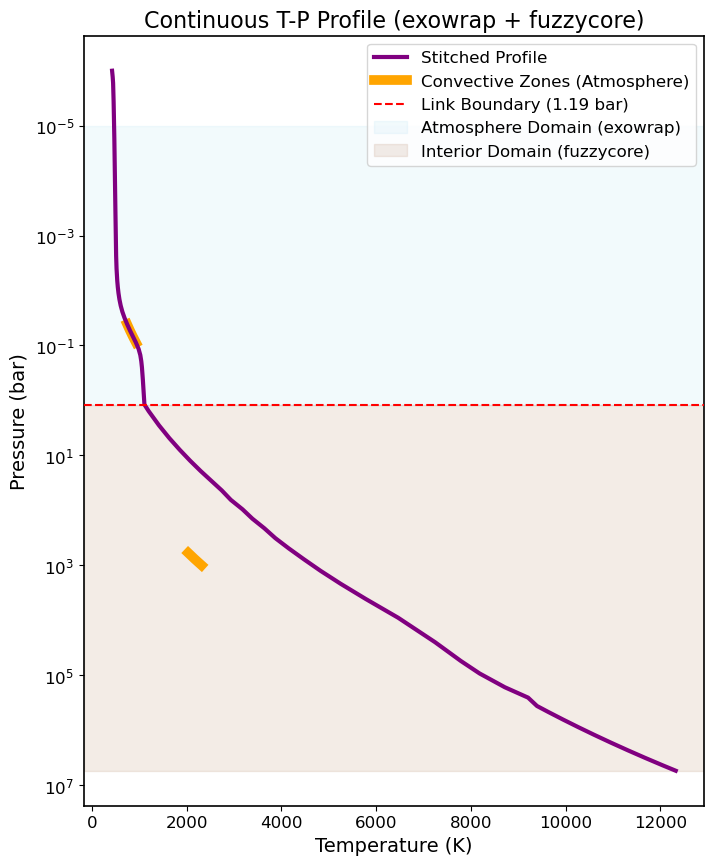

In [9]:
# 6. Visualize the continuous planetary profile
if results_fuzzy['status'] == 'converged':
    df = results_fuzzy['stitched_profile']
    p_link = results_fuzzy['final_params']['p_link_bar']
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the full stitched profile
    ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Extract and overlay the convective zones from the atmosphere!
    atm_raw = results_fuzzy['atmosphere_raw']
    p_atm_bar = atm_raw['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm = atm_raw['/outputs/levels/temperature'].iloc[0]
    is_conv = atm_raw['/outputs/levels/is_convective'].iloc[0].astype(bool)
    
    # Replace all non-convective temperatures with NaN
    t_conv = np.where(is_conv, t_atm, np.nan)
    
    # Plot the bold overlay (Matplotlib automatically skips the NaNs!)
    ax.plot(t_conv, p_atm_bar, color='orange', lw=7, zorder=2, label='Convective Zones (Atmosphere)')
    
    # 3. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 4. Format the axes for atmospheric science standards (log pressure, inverted)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)
    
    # 5. Fill background colors to show domains
    ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')
    
    ax.legend(loc='upper right')
    plt.show()

Figure saved to: ../figures/structure_diagnostics.pdf


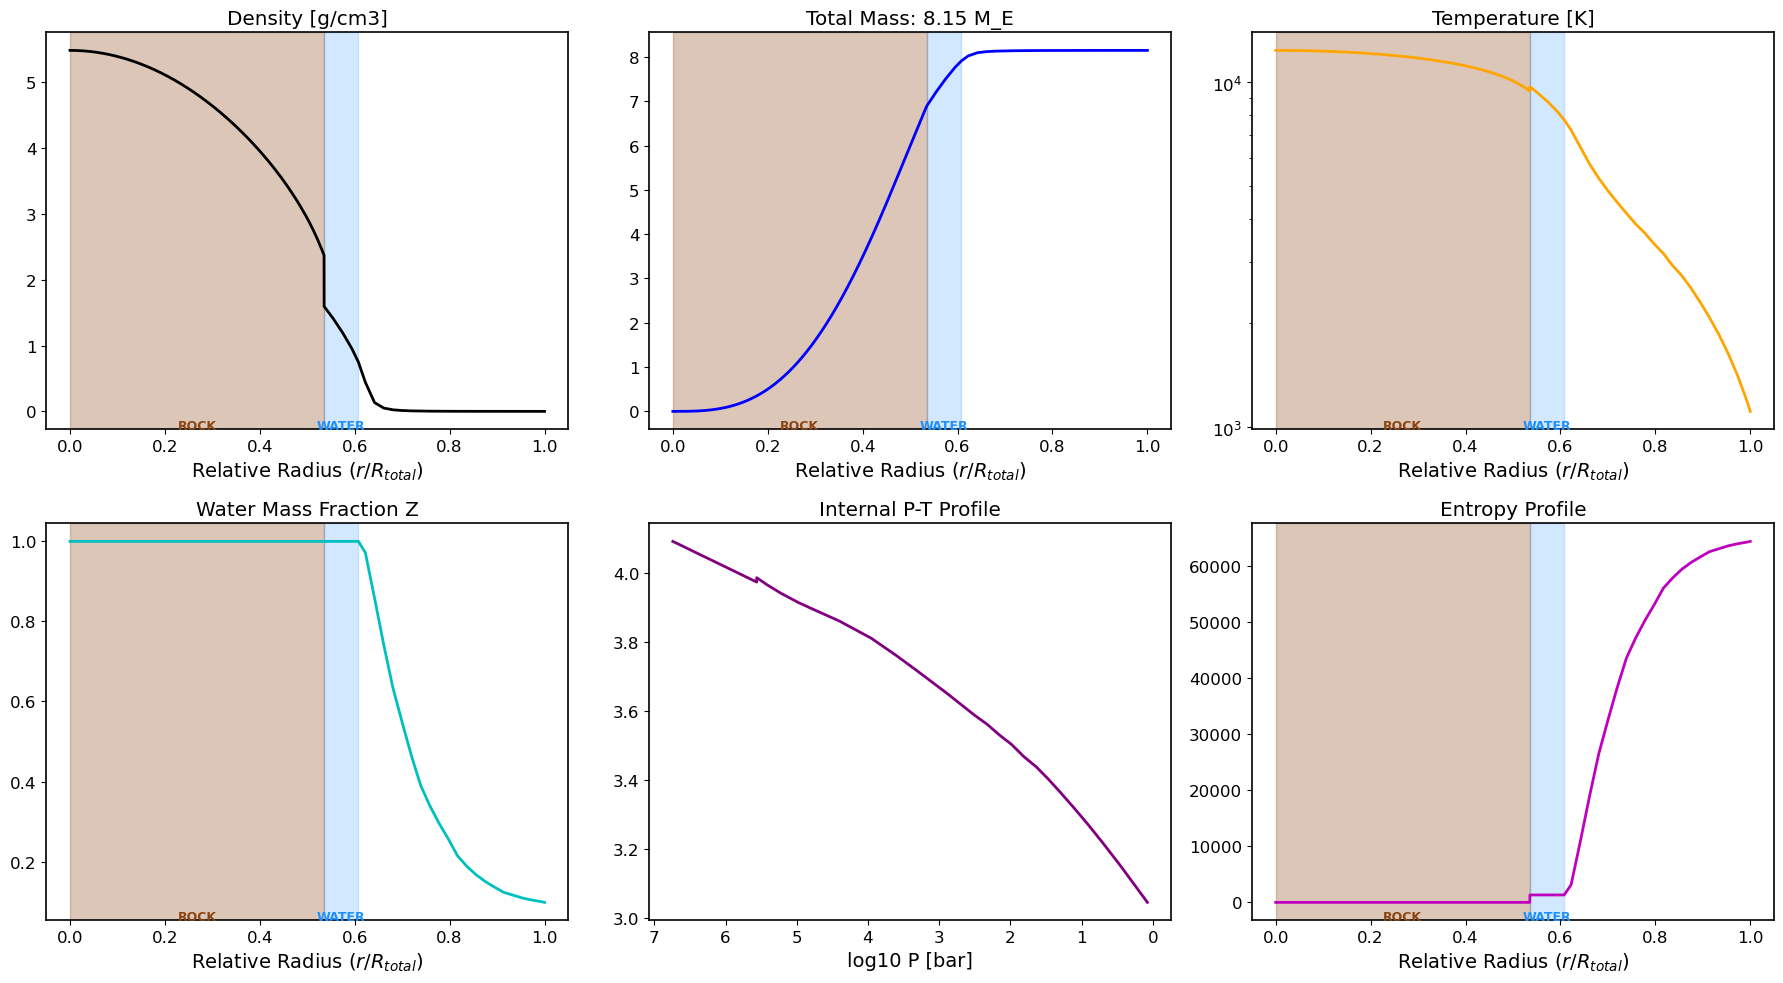

In [11]:
from fuzzycore.plotting import plot_diagnostics

plot_diagnostics(results_fuzzy['interior_raw'])